<ipython-input-2-d5806febcccf>:14: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drebin-215-dataset-5560malware-9476-benign.csv')  # Change file name as needed


   transact  onServiceConnected  bindService  attachInterface  \
0         0                   0            0                0   
1         0                   0            0                0   
2         0                   0            0                0   
3         0                   0            0                0   
4         0                   0            0                0   

   ServiceConnection  android.os.Binder  SEND_SMS  \
0                  0                  0         1   
1                  0                  0         1   
2                  0                  0         1   
3                  0                  0         0   
4                  0                  0         0   

   Ljava.lang.Class.getCanonicalName  Ljava.lang.Class.getMethods  \
0                                  0                            0   
1                                  0                            0   
2                                  0                            0   
3             

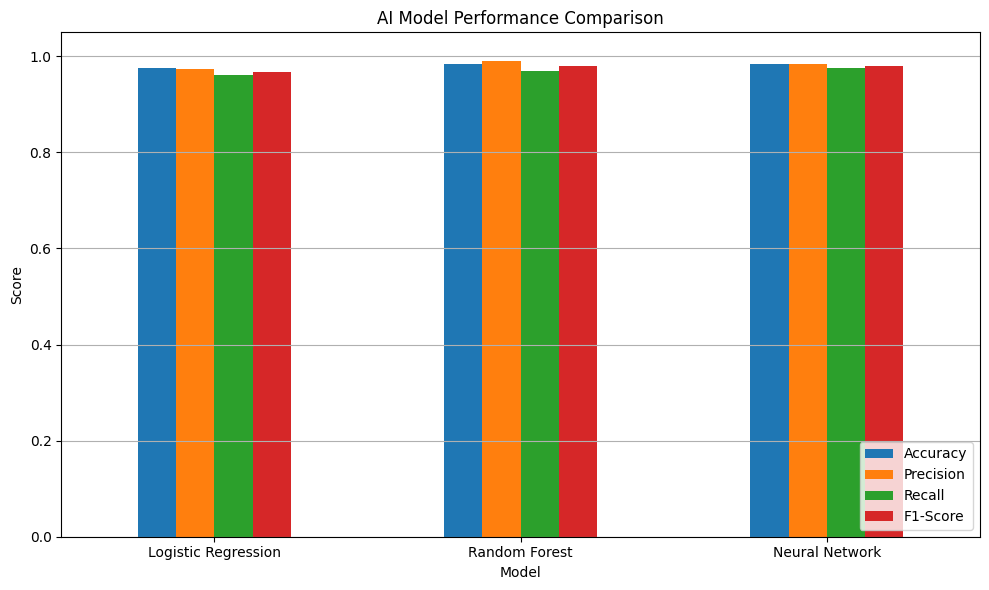

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load and Preprocess Dataset
df = pd.read_csv('/content/drebin-215-dataset-5560malware-9476-benign.csv')  # Change file name as needed
print(df.head())

# Handle missing values
df = df.dropna()

# Replace '?' with NaN
df = df.replace('?', np.nan)

# Impute NaN with the most frequent value for each column (you can change the strategy if needed)
for column in df.columns:
    # Get the most frequent value
    most_frequent_value = df[column].mode()[0]
    # Impute missing values with the most frequent value
    df[column] = df[column].fillna(most_frequent_value)


# Encode categorical labels
label_encoder = LabelEncoder()
df['class'] = label_encoder.fit_transform(df['class'])  # 'malicious'=1, 'benign'=0

# Split features and target
X = df.drop('class', axis=1)
y = df['class']

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Step 3: Train Models
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    print(f"\n{name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 4: Performance Graph
results_df = pd.DataFrame(results)
results_df.set_index('Model', inplace=True)
results_df.plot(kind='bar', figsize=(10, 6))
plt.title("AI Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()